# Task 2: Supervised Learning
**Research question:** Can weather and time conditions predict whether Hanoi's air quality will reach a warning level?

> **Note:** The PM2.5 model is intentionally treated as an extra experiment, not part of the regular model ranking, because it uses additional pollution-sensor information rather than only weather and time features.

## 2.1 Import libraries
This section imports the Python packages required for the full supervised-learning workflow. pandas and numpy are used for data handling, matplotlib is used for visualisations, and scikit-learn provides preprocessing tools, classifiers, model-selection methods, and evaluation metrics. A fixed RANDOM_STATE is used where possible so that model training and tuning results are reproducible.


In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, classification_report
)

RANDOM_STATE = 42

## 2.2 Load the dataset

In [26]:
df = pd.read_csv('data/hanoi_air_quality_clean.csv', parse_dates=['timestamp'])

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset shape: (8760, 14)
Date range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00

Columns: ['timestamp', 'temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week', 'is_weekend', 'wind_direction', 'precipitation', 'cloud_cover', 'is_warning', 'aqi', 'pm25']


,timestamp,temperature,humidity,wind_speed,pressure,hour,day_of_week,is_weekend,wind_direction,precipitation,cloud_cover,is_warning,aqi,pm25
0,2025-01-01 00:00:00,14.1,91,1.138889,1016.6,0,2,0,319,0.0,0,1,158,111.3
1,2025-01-01 01:00:00,13.5,93,1.277778,1016.6,1,2,0,321,0.0,4,1,159,112.7
2,2025-01-01 02:00:00,12.9,94,1.083333,1016.1,2,2,0,317,0.0,0,1,160,113.2
3,2025-01-01 03:00:00,12.6,96,1.277778,1015.5,3,2,0,315,0.0,0,1,162,113.9
4,2025-01-01 04:00:00,12.4,96,1.277778,1015.4,4,2,0,312,0.0,2,1,163,115.5


## 2.3 Basic data check
Before building any models, this section checks the structure and quality of the dataset. It shows the target-class distribution and displays summary statistics. This is important because classification performance can be strongly affected by class imbalance and unexpected feature ranges.

In [27]:
print("\nTarget distribution:")
print(df["is_warning"].value_counts())
print(df["is_warning"].value_counts(normalize=True).round(3))

df.describe().T


Target distribution:
is_warning
1    6709
0    2051
Name: count, dtype: int64
is_warning
1    0.766
0    0.234
Name: proportion, dtype: float64


,count,mean,min,25%,50%,75%,max,std
timestamp,8760,2025-07-02 11:30:00,2025-01-01 00:00:00,2025-04-02 05:45:00,2025-07-02 11:30:00,2025-10-01 17:15:00,2025-12-31 23:00:00,NaN
temperature,8760.0,23.891598,7.3,20.0,24.7,27.7,37.8,5.380846
humidity,8760.0,79.402511,26.0,70.0,82.0,92.0,100.0,14.865277
wind_speed,8760.0,2.405533,0.0,1.416667,2.277778,3.222222,9.555556,1.29956
pressure,8760.0,1009.156427,986.5,1003.2,1008.8,1015.2,1032.1,7.529136
hour,8760.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922582
day_of_week,8760.0,2.99726,0.0,1.0,3.0,5.0,6.0,1.998056
is_weekend,8760.0,0.284932,0.0,0.0,0.0,1.0,1.0,0.451408
wind_direction,8760.0,142.330822,1.0,63.0,134.5,169.0,360.0,99.267179
precipitation,8760.0,0.273482,0.0,0.0,0.0,0.1,28.8,1.135449


## 2.4 Define target and avoid data leakage

The target variable is `is_warning`, where `1` represents a warning-level observation and `0` represents a non-warning observation.

A key modelling decision is to **exclude `aqi`** from the input features. Since the warning label is directly derived from the AQI threshold, including AQI would allow the model to almost trivially recover the answer — this is data leakage and would produce unrealistically strong results.

The regular models therefore use only six weather and time features:
- `temperature`, `humidity`, `wind_speed`, `pressure`, `hour`, `day_of_week`

The code also creates `month` and `season` from the timestamp. `season` is used **only** to construct a fairer train/test split and to evaluate seasonal performance — it is not an input feature.

In [28]:
# Convert timestamp for sorting
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)

# Create season column for splitting/evaluation only (NOT a model input feature)
def month_to_season(month):
    if month in [1, 2, 3]:
        return "Spring"
    elif month in [4, 5, 6]:
        return "Summer"
    elif month in [7, 8, 9]:
        return "Autumn"
    else:
        return "Winter"

if "timestamp" in df.columns:
    df["month"] = df["timestamp"].dt.month
    df["season"] = df["month"].apply(month_to_season)

# Anti-leakage check: is_warning is usually defined by AQI > 100
if "aqi" in df.columns:
    match_rate = (df["is_warning"] == (df["aqi"] > 100).astype(int)).mean()
    print(f"Match rate between is_warning and (aqi > 100): {match_rate:.3f}")
    print("=> AQI is almost perfectly aligned with the label. Excluding it to prevent data leakage.")

main_features = [
    "temperature",
    "humidity",
    "wind_speed",
    "pressure",
    "hour",
    "day_of_week"
]

target = "is_warning"

print("\nMain model features:", main_features)
print("Target variable     :", target)
print("Season column       : used for splitting/evaluation only, NOT a model input feature")

Match rate between is_warning and (aqi > 100): 1.000
=> AQI is almost perfectly aligned with the label. Excluding it to prevent data leakage.

Main model features: ['temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week']
Target variable     : is_warning
Season column       : used for splitting/evaluation only, NOT a model input feature


## 2.5 Train/test split

Because the dataset is hourly time-series data spanning one full year, a purely random split would mix earlier and later observations and could create seasonal imbalance.

To address this, we use a **season-aware chronological 70/30 split**:
1. Separate data into Spring, Summer, Autumn, and Winter.
2. Within each season, take the **earlier 70%** for training and the **later 30%** for testing.
3. Combine the seasonal training parts → one training set; combine testing parts → one testing set.

This ensures the test set is always "later in time" within each season, while guaranteeing every season is represented in both splits.

In [29]:
def seasonal_chronological_split(df, features, target="is_warning", train_size=0.7):
    train_parts = []
    test_parts = []

    for season in ["Spring", "Summer", "Autumn", "Winter"]:
        season_df = df[df["season"] == season].sort_values("timestamp").copy()
        split_index = int(len(season_df) * train_size)
        train_parts.append(season_df.iloc[:split_index])
        test_parts.append(season_df.iloc[split_index:])

    train_df = pd.concat(train_parts).sort_values("timestamp").reset_index(drop=True)
    test_df  = pd.concat(test_parts).sort_values("timestamp").reset_index(drop=True)

    X_train = train_df[features].copy()
    y_train = train_df[target].copy()
    X_test  = test_df[features].copy()
    y_test  = test_df[target].copy()

    return X_train, X_test, y_train, y_test, train_df, test_df


DEFAULT_TRAIN_SIZE = 0.7

X_train, X_test, y_train, y_test, train_df, test_df = seasonal_chronological_split(
    df, main_features, target, train_size=DEFAULT_TRAIN_SIZE
)

print("Season-aware chronological split")
print(f"  Train ratio : {DEFAULT_TRAIN_SIZE}  ({X_train.shape[0]} samples)")
print(f"  Test ratio  : {round(1 - DEFAULT_TRAIN_SIZE, 2)}  ({X_test.shape[0]} samples)")
print(f"  Train warning rate : {y_train.mean():.3f}")
print(f"  Test  warning rate : {y_test.mean():.3f}")

print("\nSeason distribution in train set:")
display(train_df["season"].value_counts().loc[["Spring", "Summer", "Autumn", "Winter"]])

print("\nSeason distribution in test set:")
display(test_df["season"].value_counts().loc[["Spring", "Summer", "Autumn", "Winter"]])

print("\nWarning rate by season — train:")
display(train_df.groupby("season")[target].mean().loc[["Spring", "Summer", "Autumn", "Winter"]].round(3))

print("\nWarning rate by season — test:")
display(test_df.groupby("season")[target].mean().loc[["Spring", "Summer", "Autumn", "Winter"]].round(3))

Season-aware chronological split
  Train ratio : 0.7  (6130 samples)
  Test ratio  : 0.3  (2630 samples)
  Train warning rate : 0.752
  Test  warning rate : 0.799

Season distribution in train set:


season
Spring    1512
Summer    1528
Autumn    1545
Winter    1545
Name: count, dtype: int64


Season distribution in test set:


season
Spring    648
Summer    656
Autumn    663
Winter    663
Name: count, dtype: int64


Warning rate by season — train:


season
Spring    0.707
Summer    0.885
Autumn    0.846
Winter    0.570
Name: is_warning, dtype: float64


Warning rate by season — test:


season
Spring    0.699
Summer    0.913
Autumn    0.753
Winter    0.830
Name: is_warning, dtype: float64

## 2.6 Evaluation helper functions

This section defines reusable functions for model evaluation and visualisation. The same functions are applied to every model so the comparison is consistent.

**`evaluate_model`** — returns accuracy, precision, recall, F1, and ROC-AUC for both train and test sets.

F1-score is reported because the task cares about identifying warning cases. However, since the warning class is the majority class, F1-score alone can be misleading. Therefore, balanced accuracy, macro F1, ROC-AUC, and the confusion matrix are also used to check whether the models perform well on both warning and no-warning hours.

In [30]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    rows = []
    for split_name, X_part, y_part in [
        ("Train", X_train, y_train),
        ("Test",  X_test,  y_test)
    ]:
        y_pred  = model.predict(X_part)
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_part)[:, 1]
        else:
            y_score = model.decision_function(X_part)

        try:
            roc_auc = roc_auc_score(y_part, y_score)
        except ValueError:
            roc_auc = np.nan

        rows.append({
            "Model":             model_name,
            "Split":             split_name,
            "Accuracy":          accuracy_score(y_part, y_pred),
            "Precision":         precision_score(y_part, y_pred, zero_division=0),
            "Recall":            recall_score(y_part, y_pred, zero_division=0),
            "F1-score":          f1_score(y_part, y_pred, zero_division=0),
            "Balanced Accuracy": balanced_accuracy_score(y_part, y_pred),
            "Macro F1":          f1_score(y_part, y_pred, average="macro", zero_division=0),
            "ROC-AUC":           roc_auc
        })

    return pd.DataFrame(rows)


def show_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=["No warning", "Warning"])
    disp.plot(values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_roc_and_pr(model, X_test, y_test, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0])
    axes[0].set_title(f"ROC Curve — {title}")

    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1])
    axes[1].set_title(f"Precision-Recall Curve — {title}")

    plt.tight_layout()
    plt.show()

## 2.7 Baseline model

A baseline that always predicts the majority class sets the floor for model comparison. If the real models cannot clearly beat this rule, their performance is not meaningful — especially when the target is imbalanced.

In [31]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_results = evaluate_model(
    baseline, X_train, y_train, X_test, y_test,
    "Baseline (majority class)"
)
display(baseline_results.round(3))

,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Baseline (majority class),Train,0.752,0.752,1.0,0.858,0.5,0.429,0.5
1,Baseline (majority class),Test,0.799,0.799,1.0,0.888,0.5,0.444,0.5


## 2.8 Required model 1 — Logistic Regression

Logistic Regression is an interpretable linear classifier. `StandardScaler` is required because the features have very different units (e.g. pressure in hPa vs. wind speed in m/s). `class_weight="balanced"` compensates for class imbalance by giving higher weight to the minority no-warning class, so the model does not simply predict the majority warning class.

In [32]:
logistic_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

logistic_results = evaluate_model(
    logistic_model, X_train, y_train, X_test, y_test,
    "Logistic Regression"
)

print("Final Logistic Regression performance using season-aware chronological split:")
display(logistic_results.round(3))

Final Logistic Regression performance using season-aware chronological split:


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Logistic Regression,Train,0.654,0.845,0.661,0.742,0.647,0.609,0.717
1,Logistic Regression,Test,0.678,0.882,0.689,0.774,0.662,0.608,0.721


## 2.9 Required model 2 — SVM (basic RBF)

SVM with an RBF kernel can learn a non-linear decision boundary between warning and no-warning cases. `probability=True` enables `predict_proba`, which makes ROC-AUC and Precision-Recall curve plotting straightforward. `class_weight="balanced"` handles class imbalance the same way as Logistic Regression.

In [33]:
svm_basic = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model",  SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        class_weight="balanced",
        probability=True,          # enables predict_proba for easier ROC/PR plotting
        random_state=RANDOM_STATE
    ))
])

svm_basic.fit(X_train, y_train)

svm_basic_results = evaluate_model(
    svm_basic, X_train, y_train, X_test, y_test,
    "SVM RBF (basic)"
)

print("SVM RBF basic — train/test performance:")
display(svm_basic_results.round(3))

SVM RBF basic — train/test performance:


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,SVM RBF (basic),Train,0.786,0.904,0.801,0.849,0.771,0.741,0.851
1,SVM RBF (basic),Test,0.711,0.854,0.771,0.810,0.623,0.605,0.699


## 2.10 Excellent-level improvement — Tuned SVM

We tune:
- `kernel`: linear or RBF
- `C`: how strongly the model penalizes mistakes
- `gamma`: how flexible the RBF boundary is

The tuning target is F1-score because the task focuses on detecting warning cases. However, because warning is the majority class, the tuned model is still interpreted together with balanced accuracy, macro F1, and ROC-AUC.

GridSearchCV was run with `probability=False` for speed. For ROC-AUC evaluation, the model uses the `decision_function` output instead of predicted probabilities, which is suitable for SVM models without probability calibration.

In [34]:
# Step 1: fast grid search (probability=False)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

svm_grid = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model",  SVC(
        class_weight="balanced",
        probability=False,
        random_state=RANDOM_STATE
    ))
])

param_grid = [
    {"model__kernel": ["linear"], "model__C": [0.1, 1, 10]},
    {"model__kernel": ["rbf"],    "model__C": [0.1, 1, 10],
                                  "model__gamma": ["scale", 0.01]}
]

grid_search = GridSearchCV(
    estimator=svm_grid,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    verbose=0
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best SVM parameters   :", best_params)
print("Best cross-validation CV F1-score      :", round(grid_search.best_score_, 4))

best_svm = grid_search.best_estimator_

tuned_svm_results = evaluate_model(
    best_svm, X_train, y_train, X_test, y_test,
    "Tuned SVM"
)

print("\nTuned SVM — train/test performance:")
display(tuned_svm_results.round(3))


Best SVM parameters   : {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best cross-validation CV F1-score      : 0.8587

Tuned SVM — train/test performance:


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Tuned SVM,Train,0.835,0.941,0.833,0.883,0.837,0.800,0.907
1,Tuned SVM,Test,0.713,0.839,0.793,0.816,0.594,0.586,0.665


## 2.11 Extra model — Random Forest

Random Forest is included as an additional model beyond the required two. It can capture non-linear patterns without requiring feature scaling and serves as a strong benchmark for the analysis section.

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test,
    "Extra: Random Forest"
)

print("Random Forest — train/test performance:")
display(rf_results.round(3))

Random Forest — train/test performance:


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Extra: Random Forest,Train,0.987,0.996,0.988,0.992,0.987,0.983,0.999
1,Extra: Random Forest,Test,0.800,0.840,0.927,0.881,0.612,0.628,0.724


## 2.12 Compare all models

All models are compared on the **test set** using several metrics. F1-score is useful for warning detection, but it is not used alone because the warning class is the majority class. Balanced accuracy, macro F1, ROC-AUC, and the confusion matrix are used to judge whether a model also performs reasonably on no-warning hours.

In [36]:
METRIC_COLS = [
    "Accuracy", "Precision", "Recall", "F1-score",
    "Balanced Accuracy", "Macro F1", "ROC-AUC"
]

all_results = pd.concat([
    baseline_results,
    logistic_results,
    svm_basic_results,
    tuned_svm_results,
    rf_results
], ignore_index=True)

all_results_rounded = all_results.copy()
all_results_rounded[METRIC_COLS] = all_results_rounded[METRIC_COLS].round(3)

print("All models — full results (train + test):")
display(all_results_rounded)

All models — full results (train + test):


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Baseline (majority class),Train,0.752,0.752,1.000,0.858,0.500,0.429,0.500
1,Baseline (majority class),Test,0.799,0.799,1.000,0.888,0.500,0.444,0.500
2,Logistic Regression,Train,0.654,0.845,0.661,0.742,0.647,0.609,0.717
3,Logistic Regression,Test,0.678,0.882,0.689,0.774,0.662,0.608,0.721
4,SVM RBF (basic),Train,0.786,0.904,0.801,0.849,0.771,0.741,0.851
5,SVM RBF (basic),Test,0.711,0.854,0.771,0.810,0.623,0.605,0.699
6,Tuned SVM,Train,0.835,0.941,0.833,0.883,0.837,0.800,0.907
7,Tuned SVM,Test,0.713,0.839,0.793,0.816,0.594,0.586,0.665
8,Extra: Random Forest,Train,0.987,0.996,0.988,0.992,0.987,0.983,0.999
9,Extra: Random Forest,Test,0.800,0.840,0.927,0.881,0.612,0.628,0.724


Filter the combined results to the test set only. The table is sorted by F1-score for readability, but the final interpretation also considers balanced accuracy, macro F1, and ROC-AUC.

In [37]:
# Test-set comparison only, sorted by F1-score
comparison_test = all_results_rounded[
    all_results_rounded["Split"] == "Test"
].sort_values("F1-score", ascending=False).reset_index(drop=True)

print("Test-set comparison (sorted by F1-score):")
display(comparison_test)

Test-set comparison (sorted by F1-score):


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Baseline (majority class),Test,0.799,0.799,1.000,0.888,0.500,0.444,0.500
1,Extra: Random Forest,Test,0.800,0.840,0.927,0.881,0.612,0.628,0.724
2,Tuned SVM,Test,0.713,0.839,0.793,0.816,0.594,0.586,0.665
3,SVM RBF (basic),Test,0.711,0.854,0.771,0.810,0.623,0.605,0.699
4,Logistic Regression,Test,0.678,0.882,0.689,0.774,0.662,0.608,0.721


Add explicit F1 and ROC-AUC ranks to the regular test-set comparison table. This makes the model ranking clearer for the report.

In [38]:
# Add explicit rank columns (excluding baseline for cleaner ranking)
ranking = comparison_test[
    comparison_test["Model"] != "Baseline (majority class)"
].copy()

ranking["F1 Rank"]      = ranking["F1-score"].rank(ascending=False, method="dense").astype(int)
ranking["ROC-AUC Rank"] = ranking["ROC-AUC"].rank(ascending=False, method="dense").astype(int)
ranking = ranking.sort_values(["F1-score", "ROC-AUC"], ascending=False)

display(ranking[["F1 Rank", "ROC-AUC Rank", "Model",
                  "Accuracy", "Precision", "Recall", "F1-score",
                  "Balanced Accuracy", "Macro F1", "ROC-AUC"]])

,F1 Rank,ROC-AUC Rank,Model,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
1,1,1,Extra: Random Forest,0.800,0.840,0.927,0.881,0.612,0.628,0.724
2,2,4,Tuned SVM,0.713,0.839,0.793,0.816,0.594,0.586,0.665
3,3,3,SVM RBF (basic),0.711,0.854,0.771,0.810,0.623,0.605,0.699
4,4,2,Logistic Regression,0.678,0.882,0.689,0.774,0.662,0.608,0.721


## 2.13 Visualize the selected required model

This section visualizes the selected required model, SVM RBF. SVM has higher warning-class F1 and captures more warning cases at the default threshold, while Logistic Regression has slightly better balanced accuracy and ROC-AUC.

The outputs include:
- Confusion matrix
- ROC curve + Precision-Recall curve side by side
- Full classification report

These outputs provide more detail than a single metric. The confusion matrix shows the number of correct and incorrect predictions, while the ROC and Precision-Recall curves show how the model behaves across different decision thresholds.

In [39]:
# Select best between the two required models only
comparison_required = comparison_test[
    comparison_test["Model"].isin(["Logistic Regression", "SVM RBF (basic)"])
].copy()

best_model_name = comparison_required.iloc[0]["Model"]
print("Best required model on test set:", best_model_name )
display(comparison_required[[
    "Model", "Accuracy", "Precision", "Recall",
    "F1-score", "Balanced Accuracy", "Macro F1", "ROC-AUC"
]].round(3))

model_dict = {
    "Logistic Regression": logistic_model,
    "SVM RBF (basic)":     svm_basic
}
best_model = model_dict[best_model_name ]

Best required model on test set: SVM RBF (basic)


,Model,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
3,SVM RBF (basic),0.711,0.854,0.771,0.810,0.623,0.605,0.699
4,Logistic Regression,0.678,0.882,0.689,0.774,0.662,0.608,0.721


In [40]:
print(f"Classification report — {best_model_name} (test set):")
print(classification_report(
    y_test,
    best_model.predict(X_test),
    target_names=["No warning", "Warning"],
    zero_division=0
))

Classification report — SVM RBF (basic) (test set):
              precision    recall  f1-score   support

  No warning       0.34      0.48      0.40       529
     Warning       0.85      0.77      0.81      2101

    accuracy                           0.71      2630
   macro avg       0.60      0.62      0.60      2630
weighted avg       0.75      0.71      0.73      2630



### Seasonal performance of the best required model

Because air quality patterns differ across seasons, we break down the best model's performance by season to identify where it succeeds or struggles.

In [41]:
def evaluate_by_season(model, test_df, features, target="is_warning"):
    rows = []

    for season in ["Spring", "Summer", "Autumn", "Winter"]:
        season_test = test_df[test_df["season"] == season].copy()

        X_season = season_test[features]
        y_season = season_test[target]

        y_pred = model.predict(X_season)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_season)[:, 1]
        else:
            y_score = model.decision_function(X_season)

        try:
            roc_auc = roc_auc_score(y_season, y_score)
        except ValueError:
            roc_auc = np.nan

        rows.append({
            "Season": season,
            "Samples": len(season_test),
            "Warning Rate": y_season.mean(),
            "Accuracy": accuracy_score(y_season, y_pred),
            "Precision": precision_score(y_season, y_pred, zero_division=0),
            "Recall": recall_score(y_season, y_pred, zero_division=0),
            "F1-score": f1_score(y_season, y_pred, zero_division=0),
            "Balanced Accuracy": balanced_accuracy_score(y_season, y_pred),
            "Macro F1": f1_score(y_season, y_pred, average="macro", zero_division=0),
            "ROC-AUC": roc_auc
        })

    return pd.DataFrame(rows)


season_results = evaluate_by_season(
    best_model,
    test_df,
    main_features,
    target
)

print("Best model performance by season:")
display(season_results.round(3))

Best model performance by season:


,Season,Samples,Warning Rate,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Spring,648,0.699,0.557,0.753,0.545,0.633,0.565,0.538,0.630
1,Summer,656,0.913,0.875,0.910,0.958,0.933,0.479,0.467,0.479
2,Autumn,663,0.753,0.757,0.820,0.868,0.843,0.644,0.652,0.744
3,Winter,663,0.830,0.655,0.892,0.664,0.761,0.637,0.569,0.696


## 2.14 Feature interpretation

For Logistic Regression, positive coefficients mean that higher values of a feature increase the predicted probability of a warning, while negative coefficients reduce it. For Random Forest, feature importance indicates which variables contributed most to the model’s decision-making.

Because Logistic Regression uses scaled features in the pipeline, the coefficients are more comparable across variables than they would be without scaling.

In [42]:
# Logistic Regression coefficients
log_reg  = logistic_model.named_steps["model"]
coef_df  = pd.DataFrame({
    "Feature":     main_features,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("Logistic Regression — scaled coefficients:")
display(coef_df.round(3))

Logistic Regression — scaled coefficients:


,Feature,Coefficient
5,day_of_week,0.182
0,temperature,0.070
4,hour,-0.095
1,humidity,-0.197
2,wind_speed,-0.592
3,pressure,-0.597


In [43]:
# Random Forest feature importance
rf_importance = pd.DataFrame({
    "Feature":    main_features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Random Forest — feature importance:")
display(rf_importance.round(3))

Random Forest — feature importance:


,Feature,Importance
3,pressure,0.236
0,temperature,0.216
2,wind_speed,0.195
1,humidity,0.128
5,day_of_week,0.120
4,hour,0.105


## Extra Exploration — PM2.5-assisted Logistic Regression

As an additional experiment (not part of the main model comparison), we tested whether including `pm25` as an extra feature improves warning prediction. This model is not used as the main required model comparison, but it helps us understand how much pollutant information can improve warning prediction.

In [44]:
sensor_features = main_features + ["pm25"]

X_train_s = train_df[sensor_features]
X_test_s  = test_df[sensor_features]

print("PM2.5-assisted features:", sensor_features)

sensor_logistic = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

sensor_logistic.fit(X_train_s, y_train)

sensor_logistic_results = evaluate_model(
    sensor_logistic,
    X_train_s, y_train,
    X_test_s,  y_test,
    "PM2.5-assisted Logistic Regression"
)

# Side-by-side comparison
pm25_comparison = pd.concat([logistic_results, sensor_logistic_results], ignore_index=True)
pm25_comparison[METRIC_COLS] = pm25_comparison[METRIC_COLS].round(4)
print("Logistic Regression vs PM2.5-assisted Logistic Regression:")
display(pm25_comparison)

PM2.5-assisted features: ['temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week', 'pm25']
Logistic Regression vs PM2.5-assisted Logistic Regression:


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Logistic Regression,Train,0.6542,0.8448,0.6615,0.7420,0.6468,0.6089,0.7171
1,Logistic Regression,Test,0.6783,0.8824,0.6892,0.7739,0.6622,0.6083,0.7209
2,PM2.5-assisted Logistic Regression,Train,0.7715,0.9201,0.7622,0.8337,0.7809,0.7342,0.8659
3,PM2.5-assisted Logistic Regression,Test,0.7738,0.9288,0.7763,0.8457,0.7700,0.7108,0.8419


In [45]:
print("Classification report — PM2.5-assisted Logistic Regression (test set):")
print(classification_report(
    y_test,
    sensor_logistic.predict(X_test_s),
    target_names=["No warning", "Warning"],
    zero_division=0
))

Classification report — PM2.5-assisted Logistic Regression (test set):
              precision    recall  f1-score   support

  No warning       0.46      0.76      0.58       529
     Warning       0.93      0.78      0.85      2101

    accuracy                           0.77      2630
   macro avg       0.70      0.77      0.71      2630
weighted avg       0.83      0.77      0.79      2630



## 2.15 Final Report Visualizations

The following figures are created specifically for the written report. They summarize the main results from the notebook without changing any model, split, or metric. Each figure supports one part of the report: required model comparison, model diagnostics, and extra exploration.

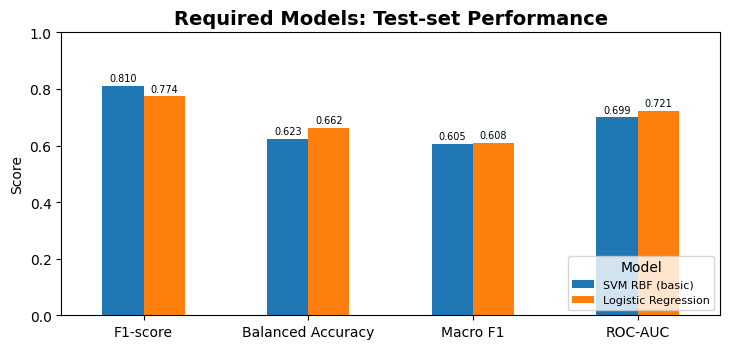

In [52]:
# Figure 1: Required model comparison for the report

required_summary = comparison_test[
    comparison_test["Model"].isin(["Logistic Regression", "SVM RBF (basic)"])
].copy()

required_summary = required_summary.set_index("Model")[
    ["F1-score", "Balanced Accuracy", "Macro F1", "ROC-AUC"]
]

fig, ax = plt.subplots(figsize=(7.4, 3.6))

required_summary.T.plot(kind="bar", ax=ax, rot=0)

ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Required Models: Test-set Performance", fontsize=14, fontweight="bold")
ax.legend(title="Model", loc="lower right", fontsize=8)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)

plt.tight_layout()
plt.savefig("visuals/task2_required_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

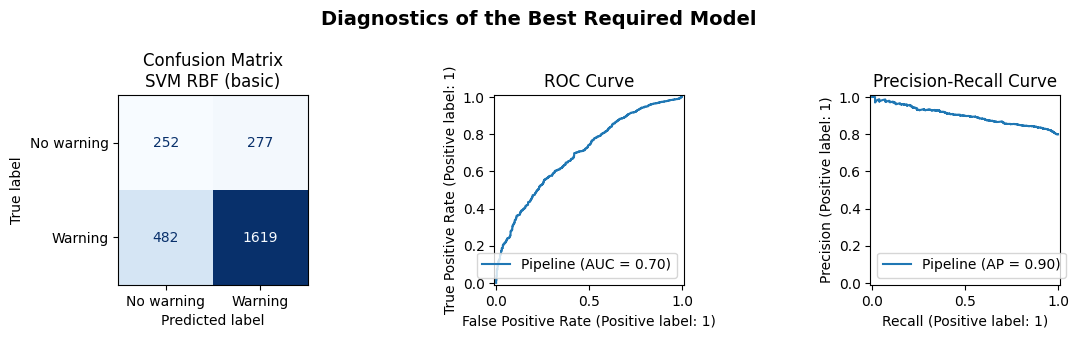

In [51]:
# Figure 2: Diagnostics of the best required model for the report

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["No warning", "Warning"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title(f"Confusion Matrix\n{best_model_name}")

# ROC curve
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=axes[1]
)
axes[1].set_title("ROC Curve")

# Precision-Recall curve
PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=axes[2]
)
axes[2].set_title("Precision-Recall Curve")

fig.suptitle("Diagnostics of the Best Required Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visuals/task2_best_required_model_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

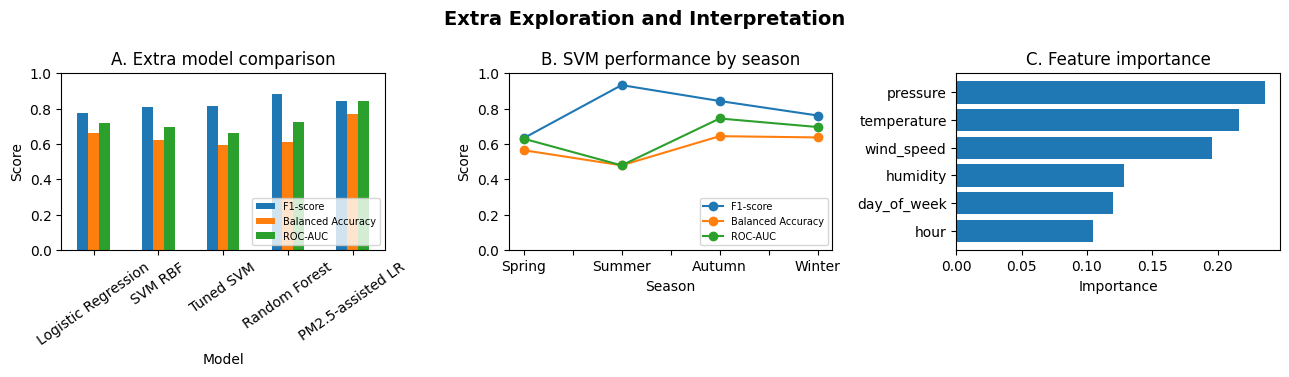

In [53]:
# Figure 3: Extra exploration and interpretation for the report

extra_test_results = pd.concat([
    all_results_rounded[all_results_rounded["Split"] == "Test"],
    sensor_logistic_results[sensor_logistic_results["Split"] == "Test"]
], ignore_index=True)

extra_test_results = extra_test_results[
    extra_test_results["Model"].isin([
        "Logistic Regression",
        "SVM RBF (basic)",
        "Tuned SVM",
        "Extra: Random Forest",
        "PM2.5-assisted Logistic Regression"
    ])
].copy()

extra_test_results["Model"] = extra_test_results["Model"].replace({
    "SVM RBF (basic)": "SVM RBF",
    "Extra: Random Forest": "Random Forest",
    "PM2.5-assisted Logistic Regression": "PM2.5-assisted LR"
})

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# Panel A: Extra model comparison
extra_plot = extra_test_results.set_index("Model")[
    ["F1-score", "Balanced Accuracy", "ROC-AUC"]
]

extra_plot.plot(kind="bar", ax=axes[0], rot=35)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score")
axes[0].set_title("A. Extra model comparison")
axes[0].legend(fontsize=7, loc="lower right")

# Panel B: Seasonal performance of best required model
season_plot = season_results.set_index("Season")[
    ["F1-score", "Balanced Accuracy", "ROC-AUC"]
]

season_plot.plot(marker="o", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Score")
axes[1].set_title("B. SVM performance by season")
axes[1].legend(fontsize=7, loc="lower right")

# Panel C: Random Forest feature importance
rf_plot = rf_importance.sort_values("Importance", ascending=True)

axes[2].barh(rf_plot["Feature"], rf_plot["Importance"])
axes[2].set_xlabel("Importance")
axes[2].set_title("C. Feature importance")

fig.suptitle("Extra Exploration and Interpretation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visuals/task2_extra_exploration_interpretation.png", dpi=300, bbox_inches="tight")
plt.show()